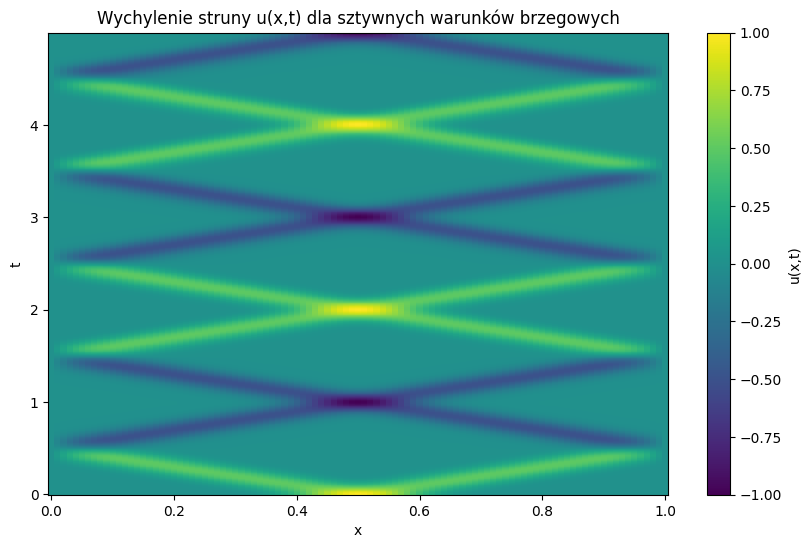

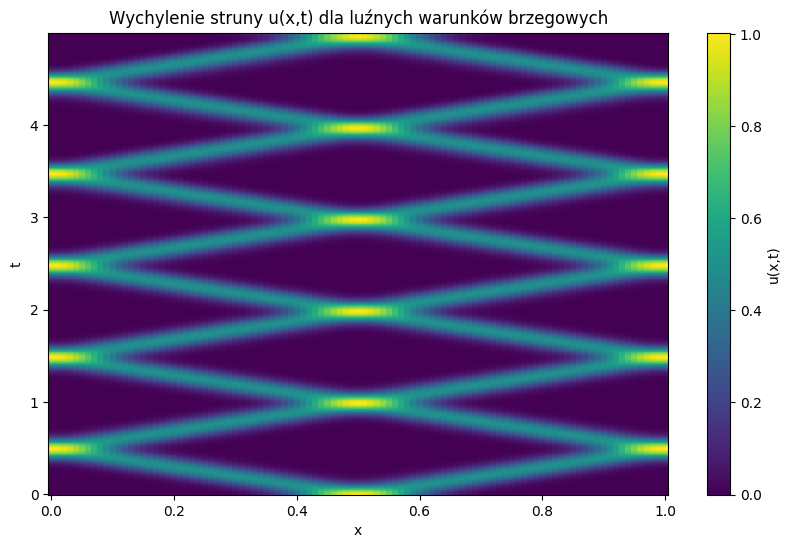

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

L=1.0
N=101
dx=L/(N-1)
x=np.linspace(0,L,N)
dt=0.005
tk=5.0
t=np.arange(0,tk,dt)
kroki=len(t)

@nb.njit
def symuluj_strune(boundary_type='fixed'):
  u_map=np.zeros((kroki, N))
  u_0=np.exp(-100*(x-0.5)**2)
  u_t=u_0.copy()
  u_prev=u_0.copy()
  u_map[0,:]=u_t
  for i in range(1, kroki):
    if boundary_type == 'free':
      u_t[0]=u_t[1]
      u_t[-1]=u_t[-2]
    elif boundary_type == 'fixed':
      u_t[0]=0
      u_t[-1]=0
    a=np.zeros(N)
    a[1:-1]=(u_t[2:]+u_t[:-2]-2*u_t[1:-1])/(dx**2)
    u_next=2*u_t-u_prev+(dt**2)*a
    u_prev=u_t.copy()
    u_t=u_next.copy()
    u_map[i,:]=u_t
  return u_map

data=symuluj_strune(boundary_type='fixed')
plt.figure(figsize=(10,6))
T,X=np.meshgrid(t,x)
plt.pcolormesh(X,T,data.T,shading='auto',cmap='viridis')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Wychylenie struny u(x,t) dla sztywnych warunków brzegowych')
plt.show()

data2=symuluj_strune(boundary_type='free')
plt.figure(figsize=(10,6))
T,X=np.meshgrid(t,x)
plt.pcolormesh(X,T,data2.T,shading='auto',cmap='viridis')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Wychylenie struny u(x,t) dla luźnych warunków brzegowych')
plt.show()


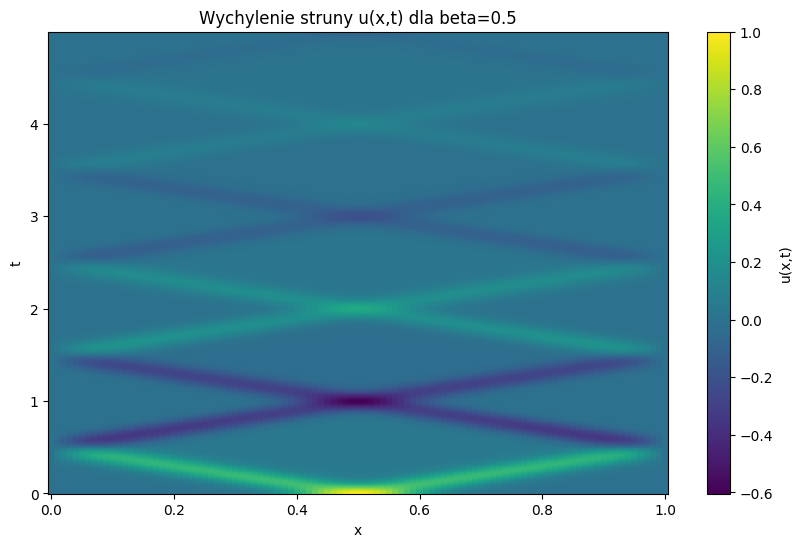

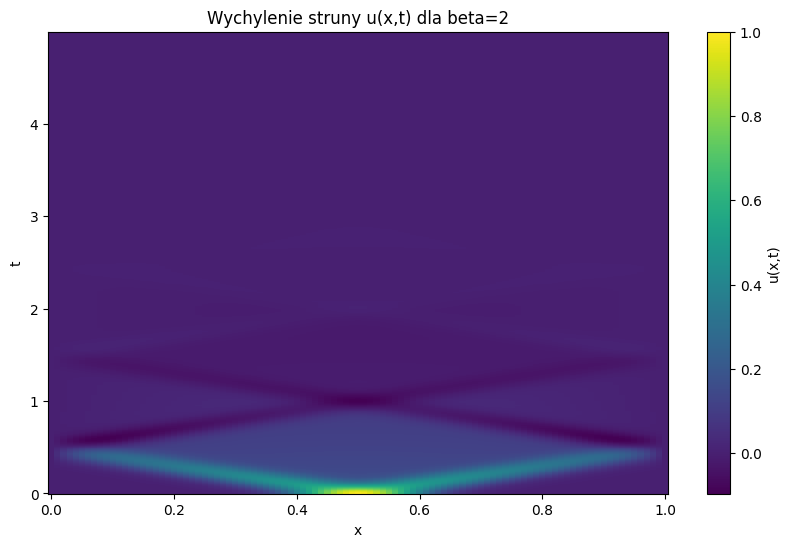

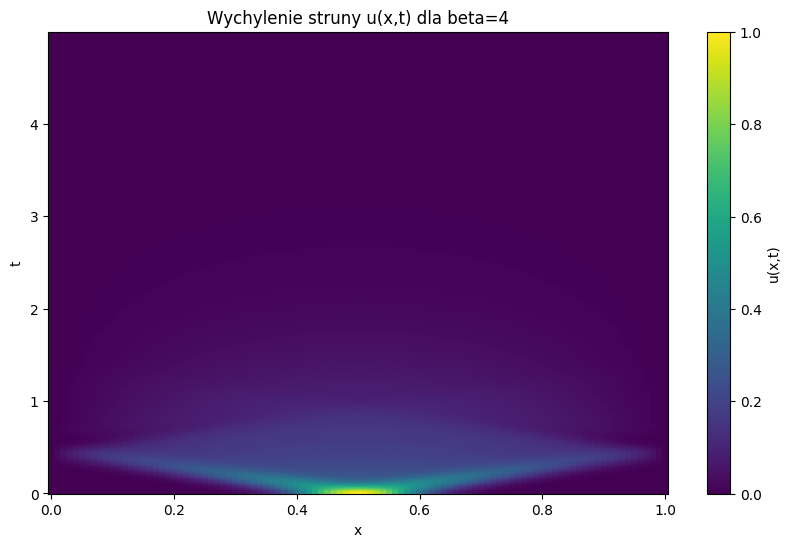

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

L=1.0
N=101
dx=L/(N-1)
x=np.linspace(0,L,N)
dt=0.005
tk=5.0
t=np.arange(0,tk,dt)
kroki=len(t)
beta_tab=[0.5,2,4]

@nb.njit
def symuluj_strune(beta):
  u_map=np.zeros((kroki, N))
  u_0=np.exp(-100*(x-0.5)**2)
  u_t=u_0.copy()
  u_prev=u_0.copy()
  u_map[0,:]=u_t
  for i in range(1, kroki):
    u_t[0]=0
    u_t[-1]=0
    a=np.zeros(N)
    a[1:-1]=(u_t[2:]+u_t[:-2]-2*u_t[1:-1])/(dx**2)-2*beta*(u_t[1:-1]-u_prev[1:-1])/dt
    u_next=2*u_t-u_prev+(dt**2)*a
    u_next[0]=0
    u_next[-1]=0
    u_prev=u_t.copy()
    u_t=u_next.copy()
    u_map[i,:]=u_t
  return u_map

for beta in beta_tab:
  data=symuluj_strune(beta)
  plt.figure(figsize=(10,6))
  T,X=np.meshgrid(t,x)
  plt.pcolormesh(X,T,data.T,shading='auto',cmap='viridis')
  plt.colorbar(label='u(x,t)')
  plt.xlabel('x')
  plt.ylabel('t')
  plt.title(f'Wychylenie struny u(x,t) dla beta={beta}')
  plt.show()

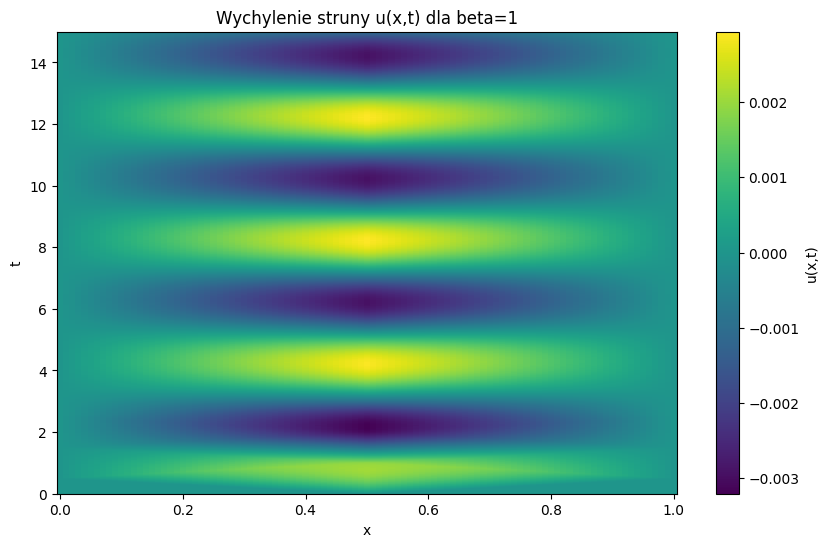

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

L=1.0
N=101
dx=L/(N-1)
x=np.linspace(0,L,N)
dt=0.005
tk=15.0
t=np.arange(0,tk,dt)
kroki=len(t)
beta=1
w=np.pi/2.0

@nb.njit
def symuluj_strune(beta,w):
  u_map=np.zeros((kroki, N))
  u_t=np.zeros(N)
  u_prev=np.zeros(N)
  idx_0=(N-1)//2
  for i in range(1, kroki):
    czas=(i-1)*dt
    a=np.zeros(N)
    a[1:-1]=(u_t[2:]+u_t[:-2]-2*u_t[1:-1])/(dx**2)-2*beta*(u_t[1:-1]-u_prev[1:-1])/dt
    a[idx_0]+=np.cos(w*czas)
    u_next=2*u_t-u_prev+(dt**2)*a
    u_next[0]=0
    u_next[-1]=0
    u_prev=u_t.copy()
    u_t=u_next.copy()
    u_map[i,:]=u_t
  return u_map

data=symuluj_strune(beta,w)
plt.figure(figsize=(10,6))
T,X=np.meshgrid(t,x)
plt.pcolormesh(X,T,data.T,shading='auto',cmap='viridis')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title(f'Wychylenie struny u(x,t) dla beta={beta}')
plt.show()

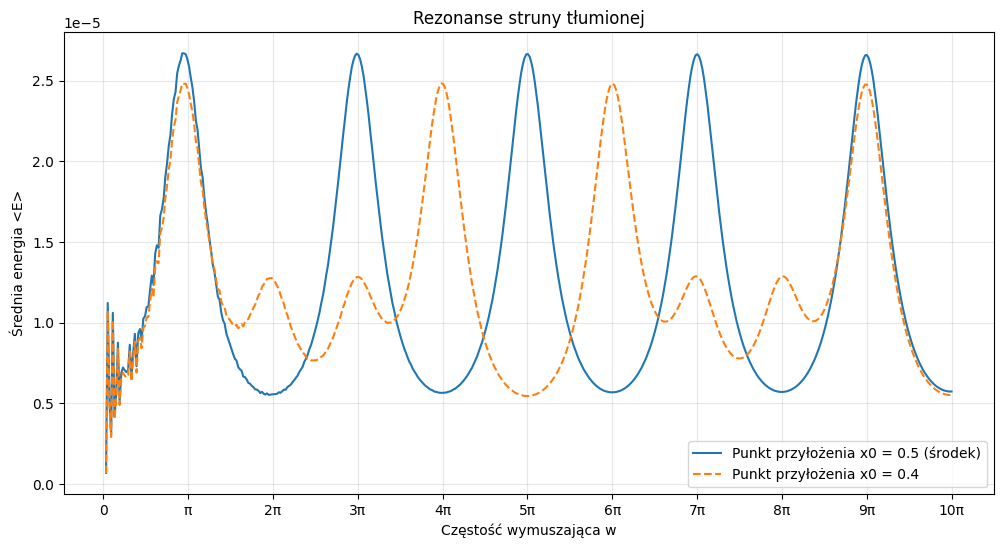

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

L=1.0
N=101
dx=L/(N-1)
x=np.linspace(0,L,N)
dt=0.005
beta=1
w=np.pi/2.0
x0_tab=[0.5,0.4]

@nb.njit
def oblicz_srednia_energie(w,x0,beta):
  tk=20.0
  t=np.arange(0,tk,dt)
  kroki=len(t)
  u_t=np.zeros(N)
  u_prev=np.zeros(N)
  idx_0=int(x0*(N-1))
  suma_energii=0.0
  licznik_krokow=0
  for i in range(1,kroki):
    czas=(i-1)*dt
    a=np.zeros(N)
    a[1:-1]=(u_t[2:]+u_t[:-2]-2*u_t[1:-1])/(dx**2)-2*beta*(u_t[1:-1]-u_prev[1:-1])/dt
    a[idx_0]+=np.cos(w*czas)
    u_next=2*u_t-u_prev+(dt**2)*a
    u_next[0]=0;u_next[-1]=0
    if czas >= 16.0:
      du_dt=(u_t-u_prev)/dt
      du_dx=np.zeros(N)
      du_dx[1:-1]=(u_t[2:]-u_t[:-2])/(2*dx)
      Et=0.5*np.sum((du_dt**2)+(du_dx**2))*dx
      suma_energii+=Et
      licznik_krokow+=1
    u_prev=u_t.copy()
    u_t=u_next.copy()
  return suma_energii/licznik_krokow if licznik_krokow > 0 else 0.0

w_tab=np.linspace(0.1,10*np.pi,500)
E_srodek=[oblicz_srednia_energie(w,x0_tab[0],beta) for w in w_tab]
E_przesunieta=[oblicz_srednia_energie(w,x0_tab[1],beta) for w in w_tab]
plt.figure(figsize=(12, 6))
plt.plot(w_tab,E_srodek,label='Punkt przyłożenia x0 = 0.5 (środek)')
plt.plot(w_tab,E_przesunieta,label='Punkt przyłożenia x0 = 0.4',linestyle='--')
plt.xticks(np.arange(0,11*np.pi,np.pi),
           ['0','π','2π','3π','4π','5π','6π','7π','8π','9π','10π'])
plt.xlabel('Częstość wymuszająca w')
plt.ylabel('Średnia energia <E>')
plt.title('Rezonanse struny tłumionej')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()